# 02 — Exploratory Data Analysis

Explore the 226k ArXiv AI papers to understand the dataset before clustering.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

df = pd.read_csv(project_root / "data" / "raw" / "arxiv_papers.csv")
df["published"] = pd.to_datetime(df["published"])
df["month"] = df["published"].dt.to_period("M")

print(f"{len(df):,} papers loaded")
print(f"{df['published'].min().date()} to {df['published'].max().date()}")

226,879 papers loaded
2024-01-01 to 2026-02-26


## Monthly Volume

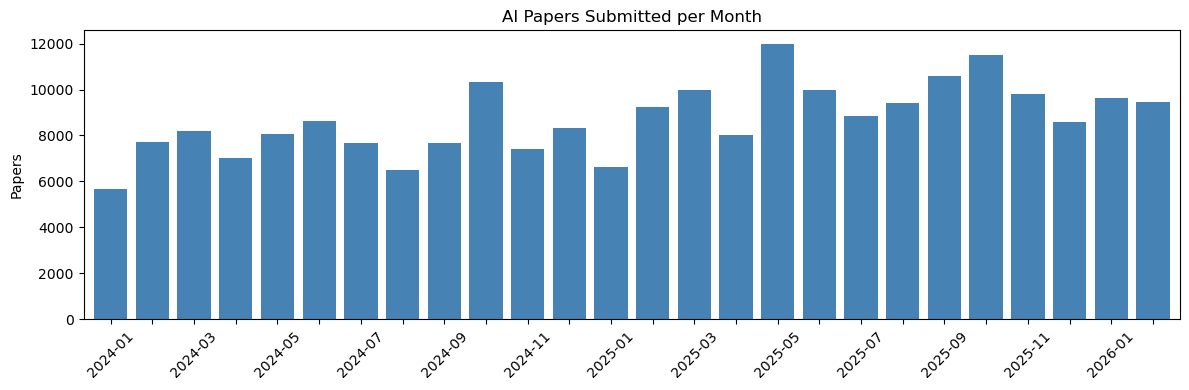

Min: 5654 (2024-01)
Max: 11979 (2025-05)
Mean: 8726


In [2]:
monthly = df.groupby("month").size()

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(kind="bar", ax=ax, width=0.8, color="steelblue")
ax.set_ylabel("Papers")
ax.set_title("AI Papers Submitted per Month")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
# Show every other label to avoid crowding
for i, label in enumerate(ax.get_xticklabels()):
    label.set_visible(i % 2 == 0)
plt.tight_layout()
plt.show()

print(f"Min: {monthly.min()} ({monthly.idxmin()})")
print(f"Max: {monthly.max()} ({monthly.idxmax()})")
print(f"Mean: {monthly.mean():.0f}")

## Category Distribution

Papers with target primary category: 181,335 (79.9%)
Papers with other primary category: 45,544


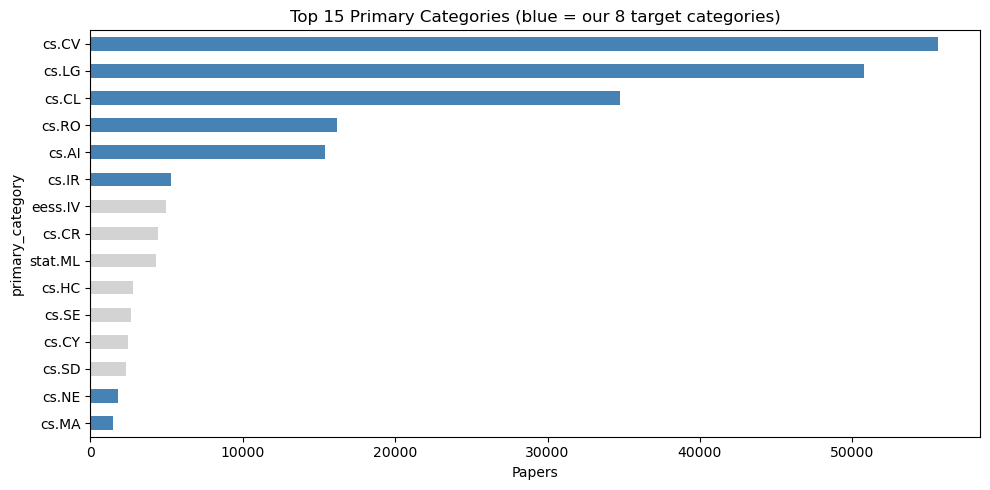

In [3]:
target_cats = {"cs.AI", "cs.LG", "cs.CL", "cs.CV", "cs.RO", "cs.NE", "cs.MA", "cs.IR"}
df["is_target"] = df["primary_category"].isin(target_cats)

print(
    f"Papers with target primary category: {df['is_target'].sum():,} "
    f"({df['is_target'].mean():.1%})"
)
print(f"Papers with other primary category: {(~df['is_target']).sum():,}")

top15 = df["primary_category"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["steelblue" if c in target_cats else "lightgray" for c in top15.index]
top15.plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Papers")
ax.set_title("Top 15 Primary Categories (blue = our 8 target categories)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Per-Category Trends Over Time

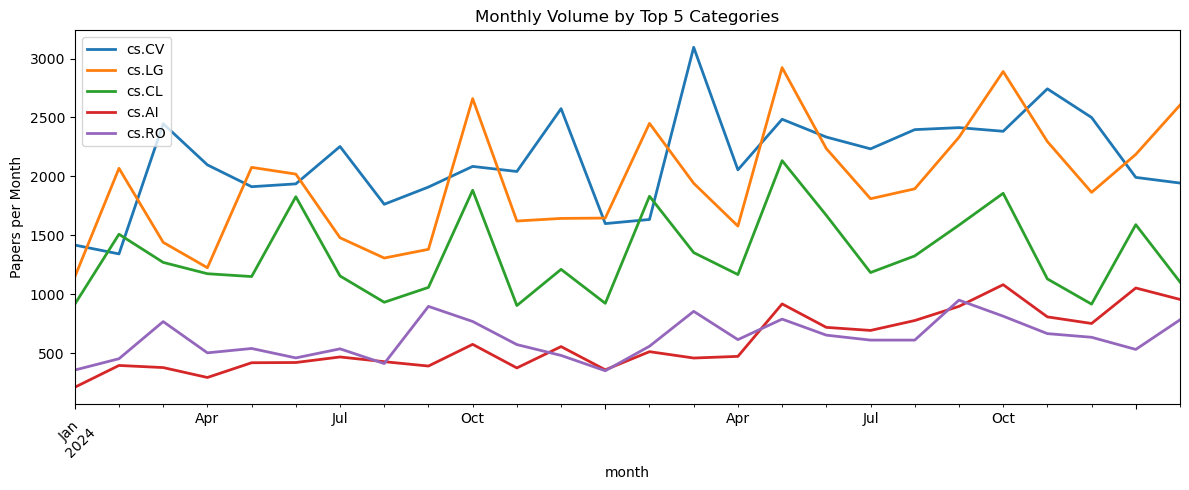

In [4]:
top5 = ["cs.CV", "cs.LG", "cs.CL", "cs.AI", "cs.RO"]

fig, ax = plt.subplots(figsize=(12, 5))
for cat in top5:
    cat_monthly = df[df["primary_category"] == cat].groupby("month").size()
    cat_monthly.plot(ax=ax, label=cat, linewidth=2)

ax.set_ylabel("Papers per Month")
ax.set_title("Monthly Volume by Top 5 Categories")
ax.legend()
ax.tick_params(axis="x", rotation=45)
for i, label in enumerate(ax.get_xticklabels()):
    label.set_visible(i % 3 == 0)
plt.tight_layout()
plt.show()

## Key Term Trends Over Time

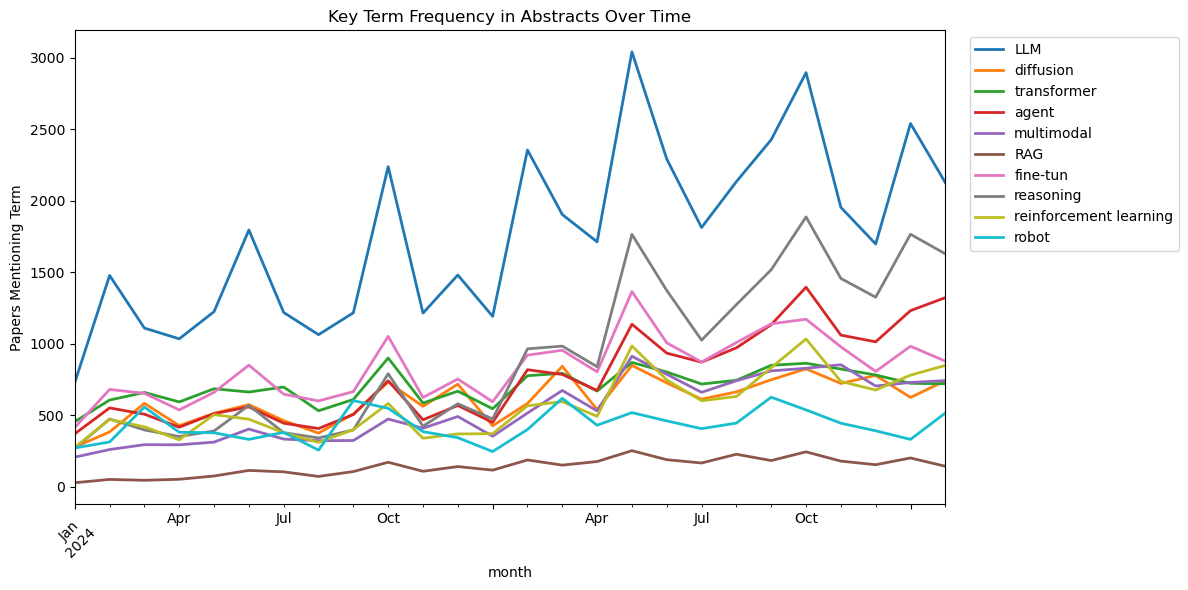

In [5]:
key_terms = {
    "LLM": r"\bLLM[s]?\b",
    "diffusion": r"\bdiffusion\b",
    "transformer": r"\btransformer[s]?\b",
    "agent": r"\bagent[s]?\b",
    "multimodal": r"\bmultimodal\b",
    "RAG": r"\bRAG\b",
    "fine-tun": r"\bfine.tun",
    "reasoning": r"\breasoning\b",
    "reinforcement learning": r"\breinforcement learning\b",
    "robot": r"\brobot[s]?\b",
}

fig, ax = plt.subplots(figsize=(12, 6))
for label, pattern in key_terms.items():
    hits = df[df["abstract"].str.contains(pattern, case=False, na=False)]
    monthly_hits = hits.groupby("month").size()
    monthly_hits.plot(ax=ax, label=label, linewidth=2)

ax.set_ylabel("Papers Mentioning Term")
ax.set_title("Key Term Frequency in Abstracts Over Time")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=45)
for i, label in enumerate(ax.get_xticklabels()):
    label.set_visible(i % 3 == 0)
plt.tight_layout()
plt.show()

## Category Co-occurrence

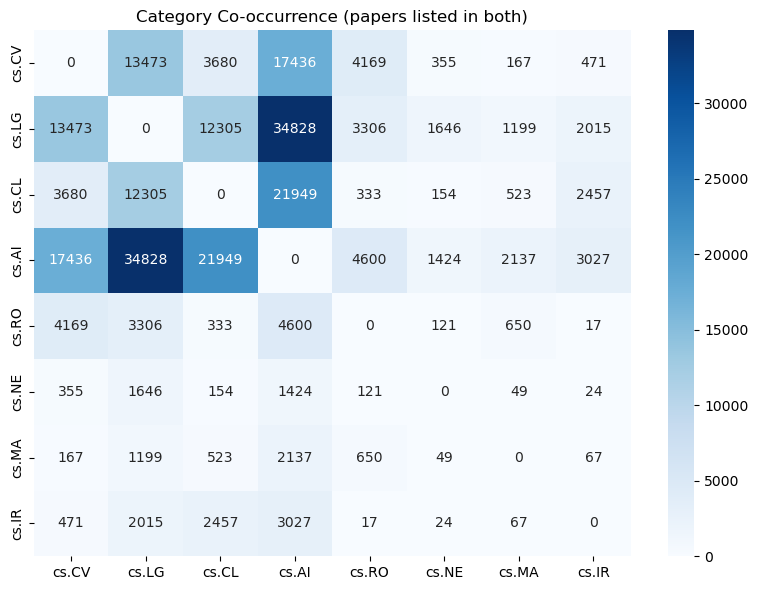

In [6]:
from itertools import combinations

target_cats_list = [
    "cs.CV",
    "cs.LG",
    "cs.CL",
    "cs.AI",
    "cs.RO",
    "cs.NE",
    "cs.MA",
    "cs.IR",
]

cooccur = pd.DataFrame(0, index=target_cats_list, columns=target_cats_list)
for _, row in df.iterrows():
    cats = [c.strip() for c in row["categories"].split(",")]
    present = [c for c in cats if c in target_cats_list]
    for a, b in combinations(present, 2):
        cooccur.loc[a, b] += 1
        cooccur.loc[b, a] += 1

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cooccur, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Category Co-occurrence (papers listed in both)")
plt.tight_layout()
plt.show()

## Author Patterns

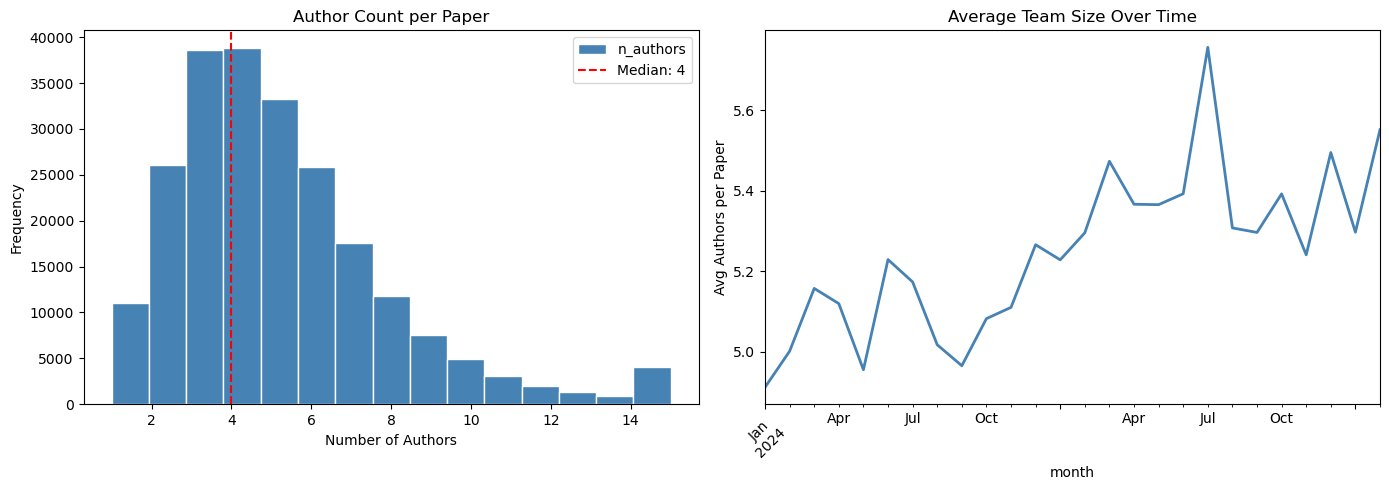

Median authors: 4
Mean authors: 5.3
Solo papers: 10,982 (4.8%)


In [ ]:
df["n_authors"] = df["authors"].str.split(",").str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Author count distribution
df["n_authors"].clip(upper=15).plot.hist(
    bins=15, ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_xlabel("Number of Authors")
axes[0].set_title("Author Count per Paper")
axes[0].axvline(
    df["n_authors"].median(),
    color="red",
    linestyle="--",
    label=f"Median: {df['n_authors'].median():.0f}",
)
axes[0].legend()

# Team size trend over time
monthly_authors = df.groupby("month")["n_authors"].mean()
monthly_authors.plot(ax=axes[1], color="steelblue", linewidth=2)
axes[1].set_ylabel("Avg Authors per Paper")
axes[1].set_title("Average Team Size Over Time")
axes[1].tick_params(axis="x", rotation=45)
for i, label in enumerate(axes[1].get_xticklabels()):
    label.set_visible(i % 3 == 0)

plt.tight_layout()
plt.show()

solo_count = (df["n_authors"] == 1).sum()
solo_pct = (df["n_authors"] == 1).mean()
print(f"Median authors: {df['n_authors'].median():.0f}")
print(f"Mean authors: {df['n_authors'].mean():.1f}")
print(f"Solo papers: {solo_count:,} ({solo_pct:.1%})")

## Abstract Length Distribution

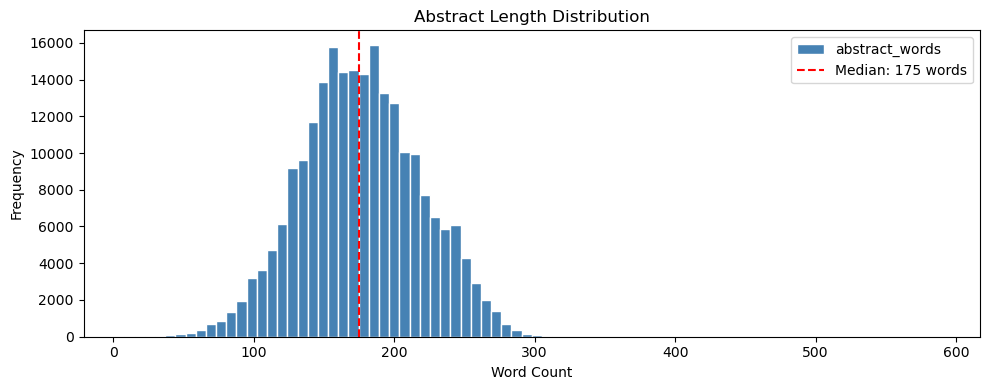

Min: 8 words
Max: 588 words
Short abstracts (<30 words): 69


In [8]:
df["abstract_words"] = df["abstract"].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 4))
df["abstract_words"].plot.hist(bins=80, ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Word Count")
ax.set_title("Abstract Length Distribution")
ax.axvline(
    df["abstract_words"].median(),
    color="red",
    linestyle="--",
    label=f"Median: {df['abstract_words'].median():.0f} words",
)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Min: {df['abstract_words'].min()} words")
print(f"Max: {df['abstract_words'].max()} words")
print(f"Short abstracts (<30 words): {(df['abstract_words'] < 30).sum()}")

## Most Prolific Authors

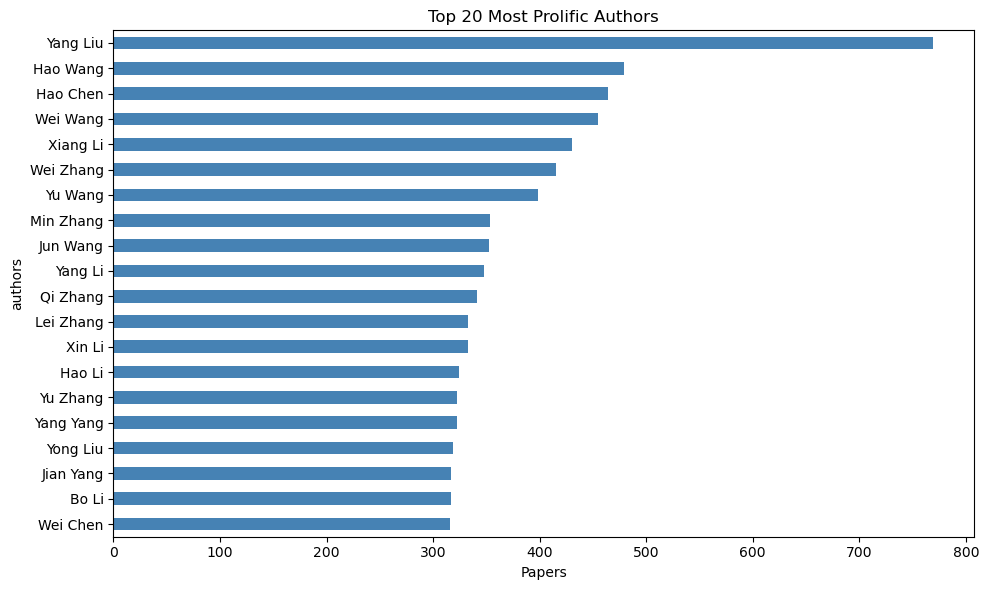

In [9]:
all_authors = df["authors"].str.split(", ").explode()
top_authors = all_authors.value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top_authors.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Papers")
ax.set_title("Top 20 Most Prolific Authors")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Reinforcement Learning Deep Dive

In [10]:
rl_pattern = (
    r"\breinforcement learning\b|\bRL\b|\bRLHF\b|\bPPO\b|\bDPO\b|\breward model"
)
df["is_rl"] = df["abstract"].str.contains(rl_pattern, case=False, na=False)

rl = df[df["is_rl"]].copy()
print(f"RL papers: {len(rl):,} ({len(rl) / len(df):.1%} of total)")

RL papers: 17,241 (7.6% of total)


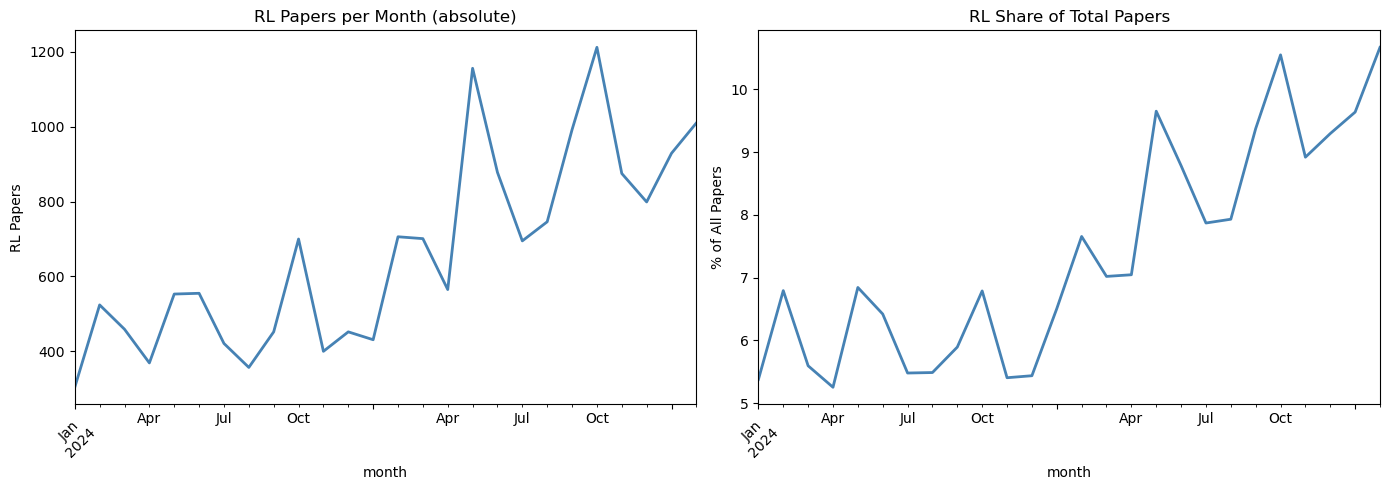

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute count
rl.groupby("month").size().plot(ax=axes[0], color="steelblue", linewidth=2)
axes[0].set_ylabel("RL Papers")
axes[0].set_title("RL Papers per Month (absolute)")
axes[0].tick_params(axis="x", rotation=45)
for i, label in enumerate(axes[0].get_xticklabels()):
    label.set_visible(i % 3 == 0)

# Share of total
rl_share = rl.groupby("month").size() / df.groupby("month").size() * 100
rl_share.plot(ax=axes[1], color="steelblue", linewidth=2)
axes[1].set_ylabel("% of All Papers")
axes[1].set_title("RL Share of Total Papers")
axes[1].tick_params(axis="x", rotation=45)
for i, label in enumerate(axes[1].get_xticklabels()):
    label.set_visible(i % 3 == 0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_61024/125153819.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hits = rl[rl["abstract"].str.contains(pattern, case=False, na=False)]
/tmp/ipykernel_61024/125153819.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hits = rl[rl["abstract"].str.contains(pattern, case=False, na=False)]
/tmp/ipykernel_61024/125153819.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hits = rl[rl["abstract"].str.contains(pattern, case=False, na=False)]
/tmp/ipykernel_61024/125153819.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hits = rl[rl["abstract"].str.contains(pattern, case=False, na=False)]


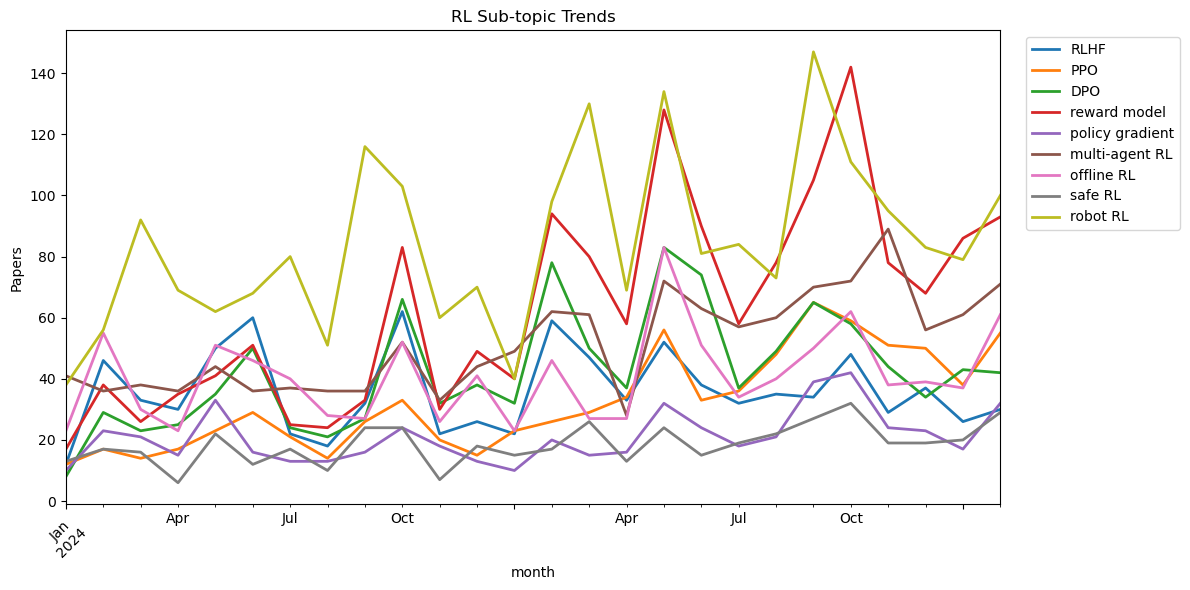

In [12]:
rl_terms = {
    "RLHF": r"\bRLHF\b",
    "PPO": r"\bPPO\b",
    "DPO": r"\bDPO\b",
    "reward model": r"\breward model",
    "policy gradient": r"\bpolicy gradient",
    "multi-agent RL": r"\bmulti.agent\b.*\b(RL|reinforcement)",
    "offline RL": r"\boffline\b.*\b(RL|reinforcement)",
    "safe RL": r"\bsafe\b.*\b(RL|reinforcement)",
    "robot RL": r"\brobot.*\b(RL|reinforcement)|\b(RL|reinforcement).*\brobot",
}

fig, ax = plt.subplots(figsize=(12, 6))
for label, pattern in rl_terms.items():
    hits = rl[rl["abstract"].str.contains(pattern, case=False, na=False)]
    monthly_hits = hits.groupby("month").size()
    if monthly_hits.sum() > 50:  # skip very rare terms
        monthly_hits.plot(ax=ax, label=label, linewidth=2)

ax.set_ylabel("Papers")
ax.set_title("RL Sub-topic Trends")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=45)
for i, label in enumerate(ax.get_xticklabels()):
    label.set_visible(i % 3 == 0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_61024/1052893168.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  count = rl["abstract"].str.contains(pattern, case=False, na=False).sum()


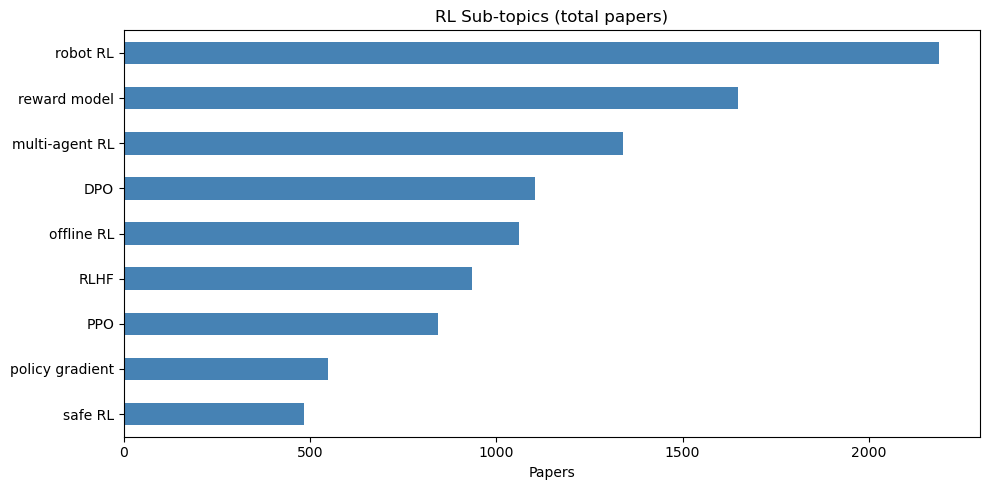

In [13]:
rl_terms = {
    "RLHF": r"\bRLHF\b",
    "PPO": r"\bPPO\b",
    "DPO": r"\bDPO\b",
    "reward model": r"\breward model",
    "policy gradient": r"\bpolicy gradient",
    "multi-agent RL": r"\bmulti.agent\b.*\b(RL|reinforcement)",
    "offline RL": r"\boffline\b.*\b(RL|reinforcement)",
    "safe RL": r"\bsafe\b.*\b(RL|reinforcement)",
    "robot RL": r"\brobot.*\b(RL|reinforcement)|\b(RL|reinforcement).*\brobot",
}

totals = {}
for label, pattern in rl_terms.items():
    count = rl["abstract"].str.contains(pattern, case=False, na=False).sum()
    if count > 50:
        totals[label] = count

fig, ax = plt.subplots(figsize=(10, 5))
pd.Series(totals).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Papers")
ax.set_title("RL Sub-topics (total papers)")
plt.tight_layout()
plt.show()

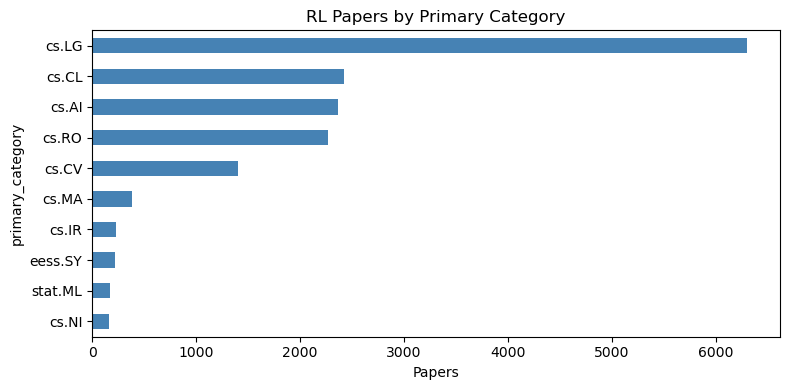

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
rl["primary_category"].value_counts().head(10).plot(
    kind="barh", ax=ax, color="steelblue"
)
ax.set_xlabel("Papers")
ax.set_title("RL Papers by Primary Category")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Robotics Deep Dive

In [15]:
robot_pattern = (
    r"\brobot[s]?\b|\bmanipulat(ion|or)\b|\blocomotion\b"
    r"|\bgrasp(ing)?\b|\bnavigat(ion|e)\b|\bautonomo(us|y)\b"
    r"|\bsim.to.real\b|\bembodied\b"
)
df["is_robot"] = df["abstract"].str.contains(robot_pattern, case=False, na=False)

robot = df[df["is_robot"]].copy()
print(f"Robotics papers: {len(robot):,} ({len(robot) / len(df):.1%} of total)")

/tmp/ipykernel_61024/4030696272.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["is_robot"] = df["abstract"].str.contains(robot_pattern, case=False, na=False)


Robotics papers: 27,677 (12.2% of total)


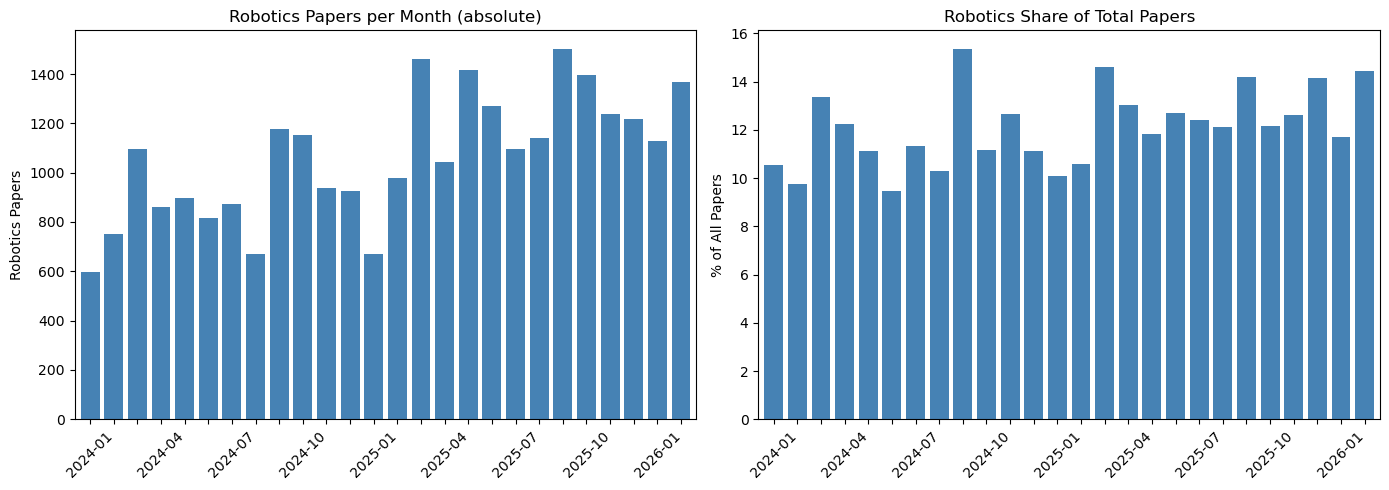

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

robot.groupby("month").size().plot(kind="bar", ax=axes[0], color="steelblue", width=0.8)
axes[0].set_ylabel("Robotics Papers")
axes[0].set_title("Robotics Papers per Month (absolute)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)
for i, label in enumerate(axes[0].get_xticklabels()):
    label.set_visible(i % 3 == 0)

robot_share = robot.groupby("month").size() / df.groupby("month").size() * 100
robot_share.plot(kind="bar", ax=axes[1], color="steelblue", width=0.8)
axes[1].set_ylabel("% of All Papers")
axes[1].set_title("Robotics Share of Total Papers")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)
for i, label in enumerate(axes[1].get_xticklabels()):
    label.set_visible(i % 3 == 0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_61024/3778684622.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  count = robot["abstract"].str.contains(pattern, case=False, na=False).sum()


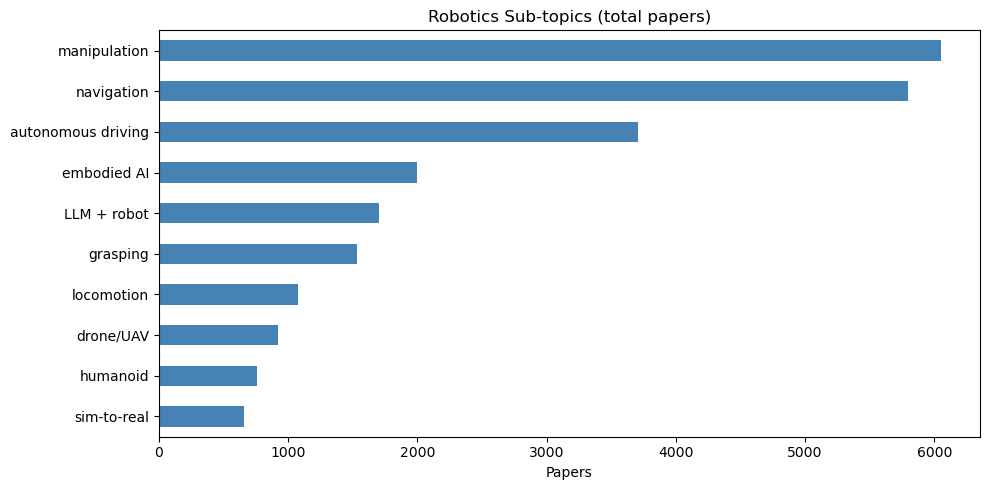

In [17]:
robot_terms = {
    "manipulation": r"\bmanipulat(ion|or|e)\b",
    "navigation": r"\bnavigat(ion|e|ing)\b",
    "grasping": r"\bgrasp(ing)?\b",
    "locomotion": r"\blocomotion\b",
    "sim-to-real": r"\bsim.to.real\b",
    "embodied AI": r"\bembodied\b",
    "humanoid": r"\bhumanoid\b",
    "drone/UAV": r"\bdrone[s]?\b|\bUAV[s]?\b",
    "autonomous driving": r"\b(autonomous|self).driv(ing|e)\b",
    "LLM + robot": r"\bLLM.*robot|\brobot.*LLM|\blanguage model.*robot",
}

totals = {}
for label, pattern in robot_terms.items():
    count = robot["abstract"].str.contains(pattern, case=False, na=False).sum()
    if count > 50:
        totals[label] = count

fig, ax = plt.subplots(figsize=(10, 5))
pd.Series(totals).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Papers")
ax.set_title("Robotics Sub-topics (total papers)")
plt.tight_layout()
plt.show()

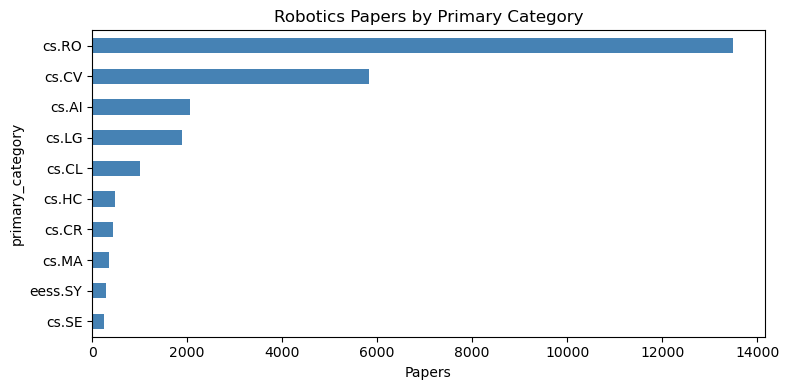

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
robot["primary_category"].value_counts().head(10).plot(
    kind="barh", ax=ax, color="steelblue"
)
ax.set_xlabel("Papers")
ax.set_title("Robotics Papers by Primary Category")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## LLM Agents Deep Dive

In [19]:
agent_pattern = (
    r"\bLLM.{0,20}agent|\bagent.{0,20}LLM"
    r"|\blanguage.{0,10}agent|\bagent(ic|s)?\b.*\blarge language"
    r"|\btool.use\b|\btool.calling\b|\bfunction.calling\b"
    r"|\bagentic\b|\bmulti.agent\b.*\bLLM"
)
df["is_agent"] = df["abstract"].str.contains(agent_pattern, case=False, na=False)

agent = df[df["is_agent"]].copy()
print(f"LLM Agent papers: {len(agent):,} ({len(agent) / len(df):.1%} of total)")

/tmp/ipykernel_61024/3102617845.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["is_agent"] = df["abstract"].str.contains(agent_pattern, case=False, na=False)


LLM Agent papers: 8,019 (3.5% of total)


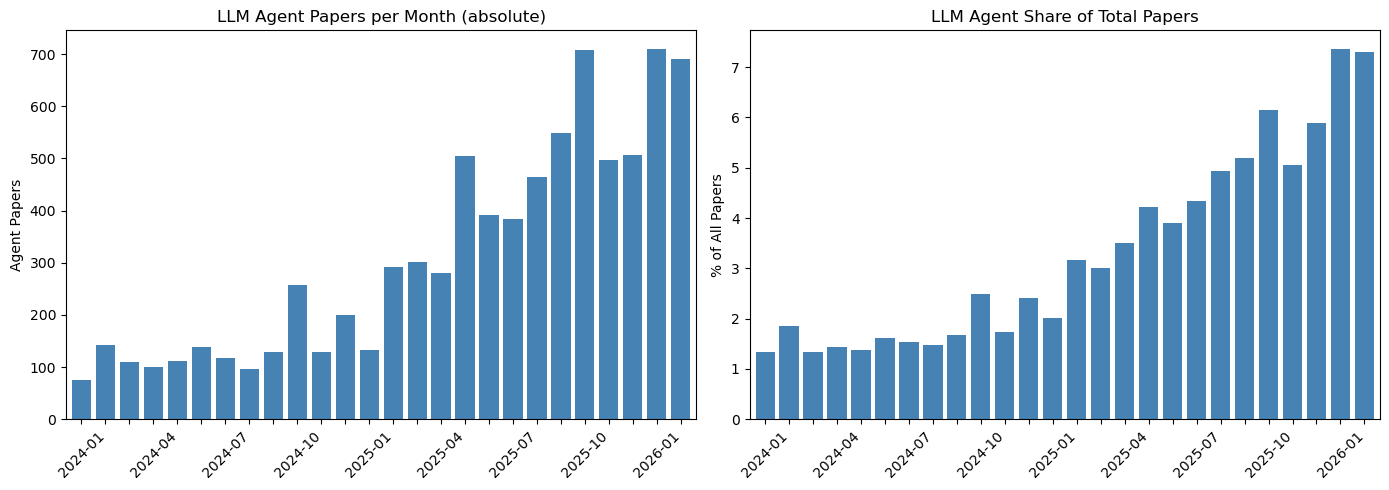

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

agent.groupby("month").size().plot(kind="bar", ax=axes[0], color="steelblue", width=0.8)
axes[0].set_ylabel("Agent Papers")
axes[0].set_title("LLM Agent Papers per Month (absolute)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)
for i, label in enumerate(axes[0].get_xticklabels()):
    label.set_visible(i % 3 == 0)

agent_share = agent.groupby("month").size() / df.groupby("month").size() * 100
agent_share.plot(kind="bar", ax=axes[1], color="steelblue", width=0.8)
axes[1].set_ylabel("% of All Papers")
axes[1].set_title("LLM Agent Share of Total Papers")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)
for i, label in enumerate(axes[1].get_xticklabels()):
    label.set_visible(i % 3 == 0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_61024/3150774139.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  count = agent["abstract"].str.contains(pattern, case=False, na=False).sum()


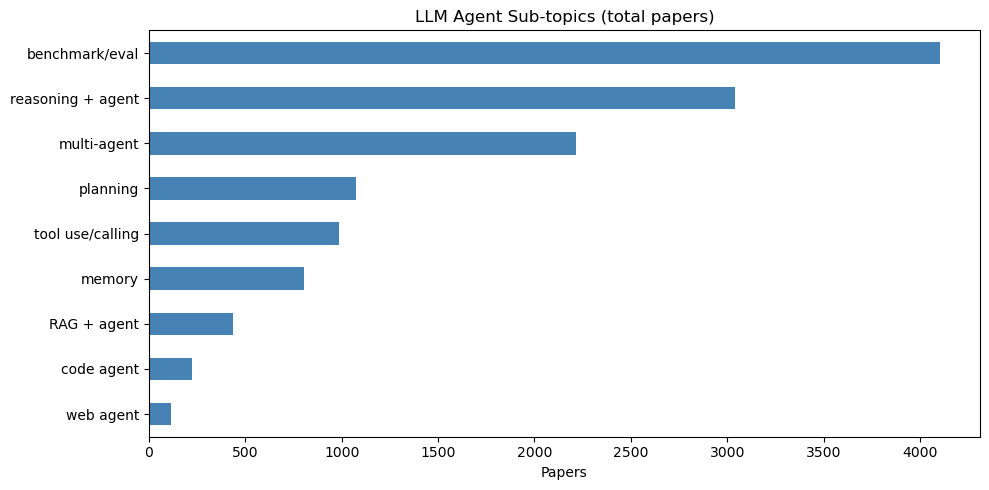

In [21]:
agent_terms = {
    "tool use/calling": r"\btool.{0,5}(use|call|using|calling)\b|\bfunction.call",
    "multi-agent": r"\bmulti.agent\b",
    "planning": r"\bplanning\b.*\bagent|\bagent.*\bplanning\b",
    "code agent": r"\bcode.{0,10}agent|\bagent.{0,10}code|\bcoding.{0,10}agent",
    "web agent": r"\bweb.{0,10}agent|\bbrows(er|ing).{0,10}agent",
    "memory": r"\bmemory\b.*\bagent|\bagent.*\bmemory\b",
    "RAG + agent": r"\bRAG\b.*\bagent|\bagent.*\bRAG\b",
    "reasoning + agent": r"\breason(ing)?\b.*\bagent|\bagent.*\breason(ing)?\b",
    "benchmark/eval": r"\bbenchmark.*\bagent|\bagent.*\bbenchmark|\beval.*\bagent",
}

totals = {}
for label, pattern in agent_terms.items():
    count = agent["abstract"].str.contains(pattern, case=False, na=False).sum()
    if count > 30:
        totals[label] = count

fig, ax = plt.subplots(figsize=(10, 5))
pd.Series(totals).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Papers")
ax.set_title("LLM Agent Sub-topics (total papers)")
plt.tight_layout()
plt.show()

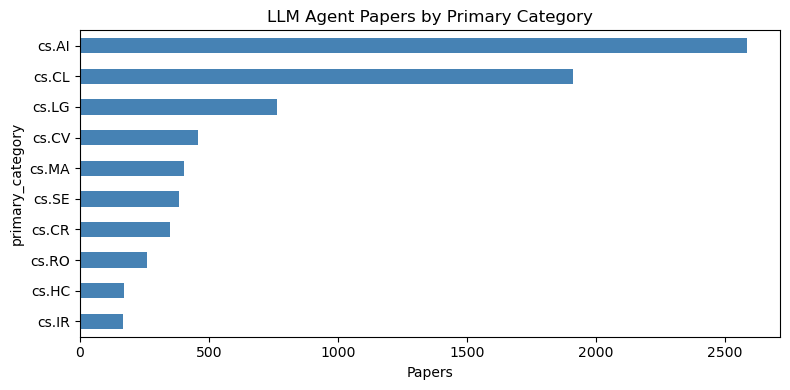

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
agent["primary_category"].value_counts().head(10).plot(
    kind="barh", ax=ax, color="steelblue"
)
ax.set_xlabel("Papers")
ax.set_title("LLM Agent Papers by Primary Category")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
# Data quality check
print(f"Duplicates: {df['arxiv_id'].duplicated().sum()}")
print(f"Missing values:\n{df.isnull().sum()}")

Duplicates: 0
Missing values:
arxiv_id            0
title               0
abstract            0
authors             0
primary_category    0
categories          0
published           0
updated             0
month               0
is_target           0
n_authors           0
abstract_words      0
is_rl               0
is_robot            0
is_agent            0
dtype: int64


## Overlap Between Focus Areas

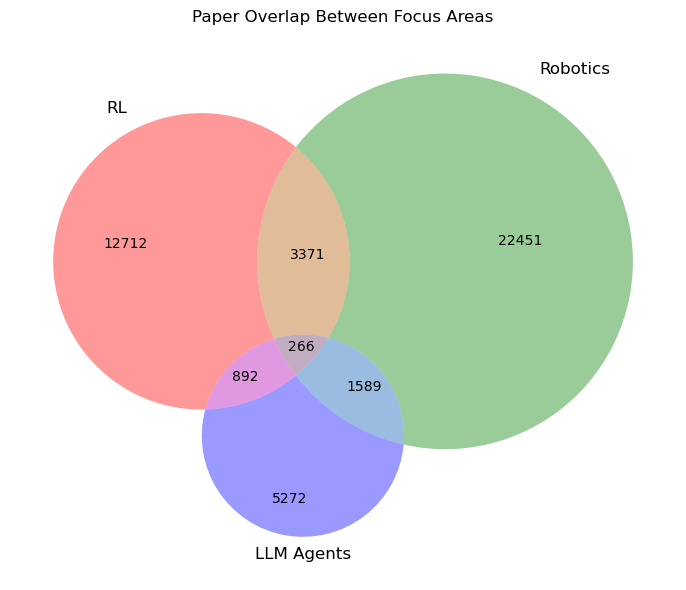

RL ∩ Robotics: 3,637
RL ∩ Agents: 1,158
Robotics ∩ Agents: 1,855
All three: 266


In [24]:
from matplotlib_venn import venn3

# Install if needed: pip install matplotlib-venn
rl_set = set(df[df["is_rl"]].index)
robot_set = set(df[df["is_robot"]].index)
agent_set = set(df[df["is_agent"]].index)

fig, ax = plt.subplots(figsize=(8, 6))
venn3(
    [rl_set, robot_set, agent_set], set_labels=("RL", "Robotics", "LLM Agents"), ax=ax
)
ax.set_title("Paper Overlap Between Focus Areas")
plt.tight_layout()
plt.show()

print(f"RL ∩ Robotics: {len(rl_set & robot_set):,}")
print(f"RL ∩ Agents: {len(rl_set & agent_set):,}")
print(f"Robotics ∩ Agents: {len(robot_set & agent_set):,}")
print(f"All three: {len(rl_set & robot_set & agent_set):,}")

## EDA Summary

**Dataset:** 226,879 papers, Jan 2024 -- Feb 2026, zero missing values.

**Overall trends:**
- Monthly submissions nearly doubled (5.6k to ~10k)
- cs.LG overtaking cs.CV as the top category in late 2025
- Average team size trending up (5.0 to 5.6 authors)
- "LLM" dominates key terms, "agent" is the fastest riser

**RL (7.6% of papers):**
- Robot RL is the largest sub-topic, reward models surging
- DPO overtook RLHF; offline RL and safe RL are niche but stable

**Robotics (12.2% of papers):**
- Manipulation and navigation dominate
- Embodied AI and LLM+robot are the emerging sub-topics
- Share holding steady at 10--14% despite LLM boom

**LLM Agents (3.5% of papers):**
- Fastest growing subfield (~10x in two years)
- Benchmark/eval and reasoning are top sub-topics
- Code agents and web agents are small but emerging

**Next:** Preprocessing and unsupervised clustering in `03_clustering.ipynb`